# Листок № 1: СЛАУ, матрицы, квадратичные формы

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display

sp.init_printing()
np.set_printoptions(precision=6, suppress=True)

### Короткая теория

Систему линейных уравнений записывают как $Ax=b$. Элементарные преобразования строк расширенной матрицы $[A\mid b]$ не меняют множество решений. В приведённой ступенчатой форме ведущие столбцы задают базисные переменные, а остальные переменные считаются свободными.

## 1.1. Общее решение СЛАУ

Найдём RREF расширенной матрицы. Свободная переменная — $x_4=t$.

In [2]:
A = sp.Matrix([[1, 5, -2, 0], [-3, 1, 9, -5], [4, -8, -1, 7]])
b = sp.Matrix([-7, 9, 0])
rref_11, pivots_11 = A.row_join(b).rref()
display(rref_11)

t = sp.symbols('t', real=True)
solution_11 = sp.Matrix([-sp.Rational(11, 7), -sp.Rational(6, 7), sp.Rational(4, 7), 0]) + t * sp.Matrix([-sp.Rational(8, 7), sp.Rational(2, 7), sp.Rational(1, 7), 1])
display(sp.Eq(sp.Symbol('x'), solution_11, evaluate=False))
assert A * solution_11 == b

⎡1  0  0  8/7   -11/7⎤
⎢                    ⎥
⎢0  1  0  -2/7  -6/7 ⎥
⎢                    ⎥
⎣0  0  1  -1/7   4/7 ⎦

    ⎡  8⋅t   11⎤
    ⎢- ─── - ──⎥
    ⎢   7    7 ⎥
    ⎢          ⎥
    ⎢ 2⋅t   6  ⎥
    ⎢ ─── - ─  ⎥
x = ⎢  7    7  ⎥
    ⎢          ⎥
    ⎢  t   4   ⎥
    ⎢  ─ + ─   ⎥
    ⎢  7   7   ⎥
    ⎢          ⎥
    ⎣    t     ⎦

Итак,
$$
(x_1,x_2,x_3,x_4)=\left(-\frac{11}{7}-\frac{8t}{7},
-\frac67+\frac{2t}{7},\frac47+\frac{t}{7},t\right),\qquad t\in\mathbb R.
$$

### Короткая теория

RREF — приведённая ступенчатая форма матрицы: в каждом ведущем столбце стоит единственная единица, а остальные элементы этого столбца равны нулю. После получения RREF свободные переменные вводят как параметры, а базисные выражают через них.

## 1.2. RREF и общее решение СЛАУ

In [3]:
A = sp.Matrix([[5, -1, 5, 9, -2], [3, 0, 6, 9, -1], [2, 0, 4, 6, -1]])
b = sp.Matrix([-3, 4, 0])
rref_12, pivots_12 = A.row_join(b).rref()
display(rref_12)

s, t = sp.symbols('s t', real=True)  # s=x3, t=x4
solution_12 = sp.Matrix([4 - 2*s - 3*t, 7 - 5*s - 6*t, s, t, 8])
display(solution_12)
assert A * solution_12 == b

⎡1  0  2  3  0  4⎤
⎢                ⎥
⎢0  1  5  6  0  7⎥
⎢                ⎥
⎣0  0  0  0  1  8⎦

⎡-2⋅s - 3⋅t + 4⎤
⎢              ⎥
⎢-5⋅s - 6⋅t + 7⎥
⎢              ⎥
⎢      s       ⎥
⎢              ⎥
⎢      t       ⎥
⎢              ⎥
⎣      8       ⎦

Ответ:
$$x=(4-2s-3t,\;7-5s-6t,\;s,\;t,\;8),\qquad s,t\in\mathbb R.$$

### Короткая теория

Если ранг матрицы системы меньше числа неизвестных, решение обычно зависит от свободных параметров. Любая координата решения является аффинной функцией этих параметров; исключив параметр между двумя координатами, можно получить зависимость одной координаты от другой.

## 1.3. Представление $y=a+bx$

У системы три независимых уравнения и четыре неизвестных, поэтому решение имеет один параметр. Выразим $x,y,z$ через $u$, а затем исключим $u$.

In [4]:
x, y, z, u = sp.symbols('x y z u')
A = sp.Matrix([[32, 97, 90, 48], [35, 84, 91, 54], [17, 18, 21, 13]])
b = sp.Matrix([47, 40, 37])
sol = next(iter(sp.linsolve((A, b), (x, y, z, u))))
display(sol)

u_from_x = sp.solve(sp.Eq(x, sol[0]), u)[0]
y_of_x = sp.expand(sol[1].subs(u, u_from_x))
display(sp.Eq(y, y_of_x))

Следовательно, $y=14027-4262x$, то есть
$$\boxed{a=14027},\qquad \boxed{b=-4262}.$$

### Короткая теория

Произведение $AB$ определено, когда число столбцов $A$ равно числу строк $B$. Его элемент вычисляется как скалярное произведение строки $A$ и столбца $B$: $(AB)_{ij}=\sum_k a_{ik}b_{kj}$. Складывать можно только матрицы одинакового размера.

## 1.4. Действия с матрицами

In [5]:
L = sp.Matrix([[3, 0, 2], [0, 1, 3], [2, 2, 0], [0, 1, 0]])
R = sp.Matrix([[1, 2, -1, 2], [-2, -1, 1, 2], [2, 1, 1, 2]])
C = sp.Matrix([[0, -4, 6, 1], [2, 2, -5, -2], [2, -2, 6, 4], [1, 3, 0, 1]])
result_14 = L * R + C
display(result_14)

⎡7   4  5   11⎤
⎢             ⎥
⎢6   4  -1  6 ⎥
⎢             ⎥
⎢0   0  6   12⎥
⎢             ⎥
⎣-1  2  1   3 ⎦

### Короткая теория

Определитель квадратной матрицы равен нулю тогда и только тогда, когда её строки или столбцы линейно зависимы. Для вычисления определителей полезны элементарные преобразования: прибавление к строке кратной другой строки определитель не меняет, перестановка меняет знак, умножение строки на число умножает определитель на это число.

## 1.5. Определители порядка $n$

После последовательного вычитания соседних строк/столбцов получаются:

1. Для $a_{ij}=\min(i,j)$: $\det A_n=1$.
2. Для $a_{ij}=\max(i,j)$: $\det A_n=(-1)^{n-1}n$.
3. Для $a_{ij}=|i-j|$: при $n\ge2$
   $$\det A_n=(-1)^{n-1}(n-1)2^{n-2},$$
   а при $n=1$ определитель равен нулю.

Проверим формулы символически для первых порядков.

In [6]:
rows_15 = []
for n in range(1, 8):
    A_min = sp.Matrix(n, n, lambda i, j: min(i + 1, j + 1))
    A_max = sp.Matrix(n, n, lambda i, j: max(i + 1, j + 1))
    A_dist = sp.Matrix(n, n, lambda i, j: abs(i - j))
    expected_dist = 0 if n == 1 else (-1)**(n-1) * (n-1) * 2**(n-2)
    rows_15.append((n, A_min.det(), A_max.det(), A_dist.det(), expected_dist))
display(sp.Matrix(rows_15))
assert all(r[1] == 1 and r[2] == (-1)**(r[0]-1)*r[0] and r[3] == r[4] for r in rows_15)

⎡1  1  1    0    0 ⎤
⎢                  ⎥
⎢2  1  -2  -1   -1 ⎥
⎢                  ⎥
⎢3  1  3    4    4 ⎥
⎢                  ⎥
⎢4  1  -4  -12  -12⎥
⎢                  ⎥
⎢5  1  5   32   32 ⎥
⎢                  ⎥
⎢6  1  -6  -80  -80⎥
⎢                  ⎥
⎣7  1  7   192  192⎦

### Короткая теория

Определитель много-линеен по строкам. Поэтому максимум модуля определителя на кубе значений $[-1,1]$ достигается в его вершинах, то есть достаточно рассматривать матрицы из $-1$ и $1$. Верхние оценки на определитель дают неравенства Адамара и Элиха.

## 1.6. Наибольший определитель шестого порядка

Нужно не просто предъявить матрицу, а проверить, что больше получить нельзя. Ниже перебор охватывает все существенно разные матрицы.

Сначала объясним, почему достаточно рассматривать элементы $\{-1,1\}$. Если зафиксировать все элементы, кроме $a_{ij}$, то $\det A$ линейно зависит от $a_{ij}$. Поэтому максимум $|\det A|$ на отрезке $[-1,1]$ достигается на его концах. Повторяя это для всех ячеек, получаем матрицу с тем же максимальным модулем определителя и без нулей.

Для любой матрицы из $\{-1,1\}$ умножением строк и столбцов на $-1$ можно сделать первую строку и первый столбец равными единице; модуль определителя от этого не меняется. Тогда матрица имеет вид
$$
H=\begin{pmatrix}1&\mathbf 1^T\\ \mathbf 1&\mathbf 1\mathbf 1^T-2B\end{pmatrix},
$$
где $B$ — бинарная матрица $5\times5$. Вычитая первую строку из остальных и раскладывая определитель по первому столбцу, получаем
$$\det H=(-2)^5\det B,\qquad |\det H|=32|\det B|.$$

Перестановка строк $B$ меняет только знак определителя. Поэтому достаточно перебрать матрицы, у которых пять двоичных строк упорядочены по возрастанию. Вместо $2^{25}=33\,554\,432$ матриц это всего
$$\binom{32+5-1}{5}=376\,992$$
случая. Следующая ячейка действительно перебирает их все.

In [7]:
from itertools import combinations_with_replacement

# Каждая строка бинарной матрицы B кодируется числом от 0 до 31.
# combinations_with_replacement перечисляет все матрицы с отсортированными
# строками, то есть по одному представителю каждого класса с точностью до
# перестановки строк.
row_masks = np.array(list(combinations_with_replacement(range(32), 5)), dtype=np.uint8)
B_all = ((row_masks[..., None] >> np.arange(5, dtype=np.uint8)) & 1).astype(np.int8)

# Детерминанты B являются целыми; округление безопасно и дополнительно
# контролируется проверкой точности ниже.
raw_dets = np.linalg.det(B_all)
det_B_all = np.rint(raw_dets).astype(int)
assert np.allclose(raw_dets, det_B_all, atol=1e-8)

max_abs_det_B = np.abs(det_B_all).max()
print(f"Перебрано нормализованных матриц B: {len(B_all):,}")
print(f"max |det(B)| = {max_abs_det_B}")

# Для положительного det(H) выбираем det(B)=-5, поскольку det(H)=(-2)^5 det(B).
best_index = np.flatnonzero(det_B_all == -max_abs_det_B)[0]
B_best = B_all[best_index]
H_best = np.ones((6, 6), dtype=int)
H_best[1:, 1:] = 1 - 2 * B_best

det_B_exact = sp.Matrix(B_best).det()
det_H_exact = sp.Matrix(H_best).det()
display(sp.Matrix(B_best))
display(sp.Matrix(H_best))
print(f"Точно: det(B) = {det_B_exact}, det(H) = {det_H_exact}")

# Полный перебор дал |det B|<=5, значит |det H|<=32*5=160.
assert max_abs_det_B == 5
assert det_H_exact == 160


Перебрано нормализованных матриц B: 376,992
max |det(B)| = 5


⎡1  1  0  0  0⎤
⎢             ⎥
⎢0  1  1  0  0⎥
⎢             ⎥
⎢1  0  1  1  0⎥
⎢             ⎥
⎢1  0  1  0  1⎥
⎢             ⎥
⎣0  1  0  1  1⎦

⎡1  1   1   1   1   1 ⎤
⎢                     ⎥
⎢1  -1  -1  1   1   1 ⎥
⎢                     ⎥
⎢1  1   -1  -1  1   1 ⎥
⎢                     ⎥
⎢1  -1  1   -1  -1  1 ⎥
⎢                     ⎥
⎢1  -1  1   -1  1   -1⎥
⎢                     ⎥
⎣1  1   -1  1   -1  -1⎦

Точно: det(B) = -5, det(H) = 160


**Вывод.** Перебор всех $376\,992$ нормализованных классов даёт $\max|\det B|=5$. Следовательно, для любой матрицы из чисел $-1,0,1$
$$|\det A|\le32\cdot5=160.$$
Построенная программой матрица $H$ имеет $\det H=160$, поэтому наибольшее **значение** определителя равно
$$\boxed{160}.$$

Таким образом, код не проверяет одну произвольную матрицу: он перебирает все варианты с точностью до преобразований, сохраняющих модуль определителя.

### Короткая теория

Для блочно-диагональной матрицы определитель равен произведению определителей блоков, а обратная матрица также состоит из обратных блоков. След обратной матрицы — сумма диагональных элементов этих обратных блоков. Разреженную структуру нужно использовать вместо создания плотной матрицы большого размера.

## 1.7. Разреженная матрица порядка 80000

Пусть
$$d_i=0.99+\frac{0.02(i-1)}{n-1}.$$
Матрица блочно-диагональна: первый блок имеет вид
$\begin{pmatrix}d_1&0.57\\0.03&d_2\end{pmatrix}$, остальные блоки — числа $d_3,\ldots,d_n$. Поэтому
$$\det A=(d_1d_2-0.57\cdot0.03)\prod_{i=3}^n d_i.$$
Чтобы избежать потери точности, произведение считаем через сумму логарифмов. Для следа обратной матрицы используем обратный первый блок:
$$\operatorname{tr}(A^{-1})=\frac{d_1+d_2}{d_1d_2-0.57\cdot0.03}+\sum_{i=3}^n\frac1{d_i}.$$

In [8]:
n = 80_000
d = np.linspace(0.99, 1.01, n)
delta = d[0] * d[1] - 0.57 * 0.03
det_A = np.exp(np.log(delta) + np.log(d[2:]).sum())
trace_inv_A = (d[0] + d[1]) / delta + np.sum(1 / d[2:])
print(f"det(A) = {det_A:.9f}")
print(f"tr(A^(-1)) = {trace_inv_A:.9f}")

det(A) = 0.258979114
tr(A^(-1)) = 80002.702766086


Ответы (как в листке, с округлением): $\boxed{0.259}$ и $\boxed{80002.703}$.

### Короткая теория

У обратимой верхнетреугольной матрицы обратная матрица тоже верхнетреугольна, а на диагонали стоят обратные к диагональным элементам числа. Если вне диагонали ненулевая только первая строка, формулы для соответствующих элементов обратной матрицы получаются из равенства $AB=I$ по одному столбцу.

## 1.8. Обратная матрица порядка 43000

Диагональ: $d_i=q^{i-1}$, где $q=1.07^{1/(n-1)}$. Первая строка: $r_i=1+0.10(i-1)/(n-1)$. Матрица верхнетреугольная, и её обратная имеет только диагональ и первую строку:

$$b_{ii}=d_i^{-1},\qquad b_{1j}=-\frac{r_j}{d_j}\;(j\ge2),$$
остальные элементы равны нулю. Минимум находится при $j=n$: $-1.10/1.07$.

In [9]:
n = 43_000
i = np.arange(n)
q = 1.07 ** (1 / (n - 1))
d = q ** i
r = 1 + 0.10 * i / (n - 1)

first_row_B = np.empty(n)
first_row_B[0] = 1.0
first_row_B[1:] = -r[1:] / d[1:]
min_B = first_row_B.min()
sum_B = np.sum(1 / d) + np.sum(first_row_B[1:])
print(f"min(B) = {min_B:.9f}")
print(f"sum(B) = {sum_B:.9f}")

min(B) = -1.028037383
sum(B) = -2054.438267011


Ответы: $\boxed{-1.028037\ldots}$ и $\boxed{-2054.438\ldots}$ (в листке: $-1.028$ и $-2054.4$).

### Короткая теория

При спектральном радиусе $
ho(A)<1$ матрический геометрический ряд сходится: $\sum_{i=m}^{\infty}A^i=(I-A)^{-1}A^m$. Конечная сумма равна разности двух таких степенных сумм. Для неотрицательной матрицы частичные суммы возрастают поэлементно к пределу.

## 1.9. Степенные суммы матрицы

Используем
$$S_{m,n}=\sum_{i=m}^nA^i,\qquad B_m=(I-A)^{-1}A^m.$$
Так как $A$ неотрицательна и её спектральный радиус меньше 1, $S_{k,n}$ монотонно возрастает поэлементно к $B_k$. Поэтому условие в пункте 3 эквивалентно $\max(B_k)<0.0002$.

In [10]:
gamma = 0.057
A = np.array([[7*gamma, 14*gamma], [9*gamma, gamma]], dtype=float)
I = np.eye(2)

S_4_70 = sum(np.linalg.matrix_power(A, i) for i in range(4, 71))
B_4 = np.linalg.solve(I - A, np.linalg.matrix_power(A, 4))

def B(k):
    return np.linalg.solve(I - A, np.linalg.matrix_power(A, k))

k = next(k for k in range(1, 1000) if B(k).max() < 2e-4)
display(S_4_70)
display(B_4)
print(f"max(S_4,70) = {S_4_70.max():.9f}")
print(f"max(B_4) = {B_4.max():.9f}")
print(f"минимальное k = {k}; max(B_k) = {B(k).max():.10f}")
assert k == 89

array([[3.609679, 3.4331  ],
       [2.206993, 2.138351]])

array([[3.611175, 3.434532],
       [2.207913, 2.139232]])

max(S_4,70) = 3.609679031
max(B_4) = 3.611174678
минимальное k = 89; max(B_k) = 0.0001846331


Ответы: $\boxed{3.609679}$, $\boxed{3.611175}$, $\boxed{89}$.

### Короткая теория

Если элементы матрицы зависят от параметра, её определитель является многочленом от этого параметра. Его степень не превосходит числа строк или столбцов, в которых встречается параметр. Коэффициенты удобно находить символьным вычислением или разложением определителя.

## 1.10. Определитель как многочлен

In [11]:
x = sp.symbols('x')
M = sp.Matrix([[7, 5, 5, x], [2, 2, 6, 9], [3, x, 8, 0], [3, 1, 1, 0]])
p = sp.Poly(sp.expand(M.det()), x)
display(sp.Eq(sp.Symbol('det(M)'), p.as_expr()))
print(f"a = {p.coeff_monomial(x**2)}, b = {p.coeff_monomial(x)}, c = {p.coeff_monomial(1)}")

a = 16, b = -116, c = 576


Ответ: $\det M=16x^2-116x+576$, поэтому $\boxed{a=16}$, $\boxed{b=-116}$.

### Короткая теория

Биномиальные коэффициенты образуют треугольник Паскаля: $\binom{n}{k}=\binom{n-1}{k-1}+\binom{n-1}{k}$. По модулю $2$ остаются только значения 0 и 1; их рисунок имеет самоподобную структуру, известную как треугольник Серпинского.

## 1.11. Биномиальные коэффициенты по модулю 2

Строка $i$ содержит $\binom{i}{j}\bmod2$ при $1\le j\le i$, а выше этой треугольной части стоят нули. Индексация соответствует примеру из условия: первая строка — $\binom11$.

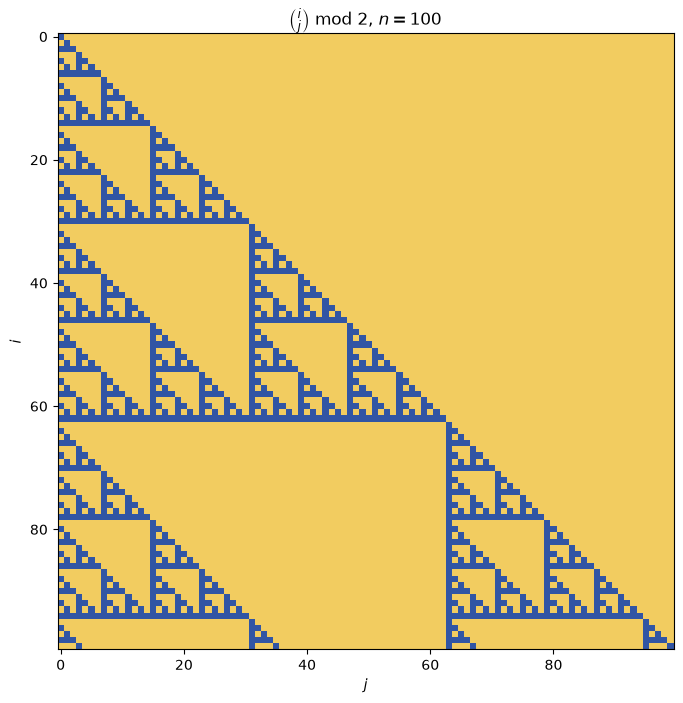

In [12]:
from math import comb

n = 100
P = np.zeros((n, n), dtype=int)
for i in range(1, n + 1):
    for j in range(1, i + 1):
        P[i - 1, j - 1] = comb(i, j) % 2

cmap_pascal = ListedColormap(['#f2cc60', '#3155a4'])  # 0 — жёлтый, 1 — синий
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(P, cmap=cmap_pascal, interpolation='nearest', origin='upper')
ax.set_title(r'$\binom{i}{j}\ \mathrm{mod}\ 2$, $n=100$')
ax.set_xlabel('$j$')
ax.set_ylabel('$i$')
plt.show()

### Короткая теория

Матрица Адамара $H$ состоит из $\pm1$ и удовлетворяет $HH^T=nI$, то есть её строки и столбцы попарно ортогональны. Конструкция Сильвестра строит матрицы порядков $2^k$ через произведение Кронекера: $H_{2^k}=H_2\otimes H_{2^{k-1}}$.

## 1.12. Матрицы Адамара

Берём стандартную конструкцию Сильвестра:
$$H_1=(1),\qquad H_2=\begin{pmatrix}1&1\\1&-1\end{pmatrix},\qquad
H_{2^k}=H_2\otimes H_{2^{k-1}}.$$

In [13]:
H1 = np.array([[1]], dtype=int)
H2 = np.array([[1, 1], [1, -1]], dtype=int)
H4 = np.kron(H2, H2)
display(sp.Matrix(H1))
display(sp.Matrix(H2))
display(sp.Matrix(H4))
print("Проверка H4 H4^T = 4I:", np.array_equal(H4 @ H4.T, 4*np.eye(4, dtype=int)))

[1]

⎡1  1 ⎤
⎢     ⎥
⎣1  -1⎦

⎡1  1   1   1 ⎤
⎢             ⎥
⎢1  -1  1   -1⎥
⎢             ⎥
⎢1  1   -1  -1⎥
⎢             ⎥
⎣1  -1  -1  1 ⎦

Проверка H4 H4^T = 4I: True


Пункт **б)** следует непосредственно из вычисления $H_2\otimes H_2$. Для **в)** применяем смешанное правило произведения Кронекера:
$$
H_{2^k}H_{2^k}^{T}
=(H_2H_2^T)\otimes(H_{2^{k-1}}H_{2^{k-1}}^T)
=2I_2\otimes 2^{k-1}I_{2^{k-1}}
=2^kI_{2^k}.
$$
Это одновременно доказывает рекурсию конструкции и свойство Адамара по индукции.

В пункте **г)** требуется $n=2^6=64$.

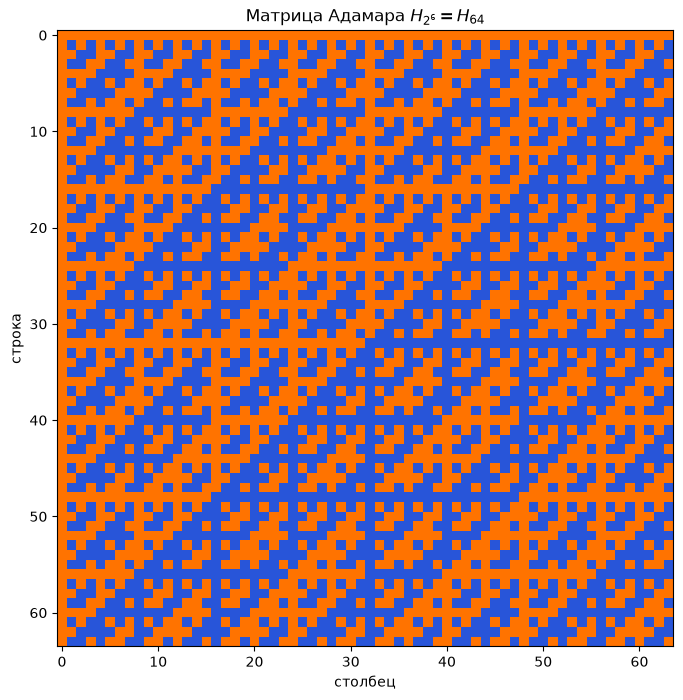

In [14]:
H64 = H1.copy()
for _ in range(6):
    H64 = np.kron(H2, H64)

assert H64.shape == (64, 64)
assert np.array_equal(H64 @ H64.T, 64*np.eye(64, dtype=int))

cmap_h = ListedColormap(['#2855d9', '#ff7300'])  # -1 — синий, +1 — оранжевый
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(H64, cmap=cmap_h, interpolation='nearest', vmin=-1, vmax=1)
ax.set_title(r'Матрица Адамара $H_{2^6}=H_{64}$')
ax.set_xlabel('столбец')
ax.set_ylabel('строка')
plt.show()

### Короткая теория

Собственные значения матрицы находятся из характеристического уравнения $\det(A-\lambda I)=0$. Для каждого значения $\lambda$ собственные векторы образуют ядро $\ker(A-\lambda I)$. У вещественной матрицы невещественные собственные значения и векторы возникают сопряжёнными парами.

## 1.13. Комплексное собственное значение и вектор

Находим все собственные значения численно, выбираем значение с наибольшей мнимой частью и нормируем соответствующий вектор так, чтобы его первая координата была равна 1.

In [15]:
A = np.array([[14, 10, 21], [12, 15, 26], [18, 11, 27]], dtype=float)
eigenvalues, eigenvectors = np.linalg.eig(A)
idx = np.argmax(eigenvalues.imag)
Z = eigenvalues[idx]
X = eigenvectors[:, idx] / eigenvectors[0, idx]
print(f"Z = {Z.real:.12f} + {Z.imag:.12f} i")
print("X =", X)
print(f"Im(Z) = {Z.imag:.12f}")
print(f"Re(U) = {X[1].real:.12f}")
assert np.allclose(A @ X, Z * X)

Z = 1.968840330802 + 0.344789348427 i
X = [ 1.      -0.j        3.74782 +1.330847j -2.357588-0.617318j]
Im(Z) = 0.344789348427
Re(U) = 3.747819729395


Ответ: $Z\approx1.968840331+0.344789348i$,
$$X\approx(1,\;3.747819729+1.330846774i,\;-2.357588427-0.617318019i).$$
Следовательно, $\boxed{\operatorname{Im}Z\approx0.344789348}$ и $\boxed{\operatorname{Re}U\approx3.747819729}$.

### Короткая теория

По теореме Гамильтона–Кэли матрица обращает в нуль свой характеристический многочлен. Минимальный многочлен — нормированный аннулирующий многочлен наименьшей степени; он делит характеристический. Степень множителя $(t-\lambda)$ равна размеру наибольшего жорданова блока для собственного значения $\lambda$.

## 1.14. Минимальный многочлен

Характеристический многочлен равен $t^3(t-1)^4$. Размер максимального жорданова блока для собственного значения $0$ равен 3, а для собственного значения $1$ — 2. Это видно по стабилизации ядер степеней $A$ и $A-I$.

In [16]:
A = sp.Matrix([
    [-3, 7, -6, -1, 8, -3, -2],
    [1, -5, 8, -3, -5, 4, -5],
    [1, 3, -4, 6, -2, 0, 8],
    [-1, 11, -12, 9, 3, -3, 9],
    [-3, 11, -12, 5, 8, -4, 6],
    [-3, 2, 1, -4, 4, 1, -7],
    [1, -5, 6, -2, -4, 3, -2],
])
t = sp.symbols('t')
charpoly = sp.factor(A.charpoly(t).as_expr())
null_A = [7 - (A**k).rank() for k in range(1, 5)]
null_A1 = [7 - ((A-sp.eye(7))**k).rank() for k in range(1, 4)]
print("Характеристический многочлен:", charpoly)
print("dim ker(A^k):", null_A)
print("dim ker((A-I)^k):", null_A1)

minimal = t**3 * (t - 1)**2
zero_check = A**3 * (A-sp.eye(7))**2
print("m(t) =", sp.factor(minimal))
assert zero_check == sp.zeros(7)

Характеристический многочлен: t**3*(t - 1)**4
dim ker(A^k): [1, 2, 3, 3]
dim ker((A-I)^k): [2, 4, 4]
m(t) = t**3*(t - 1)**2


Ответ: $\boxed{m_A(t)=t^3(t-1)^2}$.

### Короткая теория

Самосопряжённый оператор в ортонормированном базисе имеет симметричную матрицу. По спектральной теореме все его собственные значения вещественны, а собственные векторы для разных собственных значений ортогональны; внутри кратного собственного подпространства можно выбрать ортонормированный базис.

## 1.15. Ортонормированный собственный базис

Для $\lambda=9$ берём два ортонормированных вектора, для $\lambda=27$ — третий:
$$
e'_1=\frac1{\sqrt2}(1,1,0),\quad
e'_2=\frac1{3\sqrt2}(1,-1,-4),\quad
e'_3=\frac13(2,-2,1).
$$

In [17]:
A = sp.Matrix([[17, -8, 4], [-8, 17, -4], [4, -4, 11]])
sqrt = sp.sqrt
P = sp.Matrix.hstack(
    sp.Matrix([1, 1, 0])/sqrt(2),
    sp.Matrix([1, -1, -4])/(3*sqrt(2)),
    sp.Matrix([2, -2, 1])/3,
)
display(P)
display(sp.simplify(P.T * A * P))
assert sp.simplify(P.T * P) == sp.eye(3)

⎡√2    √2        ⎤
⎢──    ──    2/3 ⎥
⎢2     6         ⎥
⎢                ⎥
⎢√2   -√2        ⎥
⎢──   ────   -2/3⎥
⎢2     6         ⎥
⎢                ⎥
⎢    -2⋅√2       ⎥
⎢0   ──────  1/3 ⎥
⎣      3         ⎦

⎡9  0  0 ⎤
⎢        ⎥
⎢0  9  0 ⎥
⎢        ⎥
⎣0  0  27⎦

В этом базисе матрица оператора равна $\boxed{\operatorname{diag}(9,9,27)}$.

### Короткая теория

Квадратичная форма имеет вид $f(x)=x^TAx$, где матрицу $A$ можно считать симметричной. Ортогональная замена $x=Py$, составленная из ортонормированных собственных векторов $A$, приводит форму к сумме $\sum_i\lambda_i y_i^2$ и задаёт её главные оси.

## 1.16. Приведение квадратичной функции к главным осям

Матрица формы:
$$A=\begin{pmatrix}3&4&0&0\\4&-3&0&0\\0&0&4&-2\\0&0&-2&1\end{pmatrix}.$$
Выберем ортогональную матрицу $P$ из нормированных собственных векторов и положим $x=Py$.

In [18]:
A = sp.Matrix([[3, 4, 0, 0], [4, -3, 0, 0], [0, 0, 4, -2], [0, 0, -2, 1]])
P = sp.Matrix.hstack(
    sp.Matrix([-1, 2, 0, 0])/sp.sqrt(5),
    sp.Matrix([2, 1, 0, 0])/sp.sqrt(5),
    sp.Matrix([0, 0, 1, 2])/sp.sqrt(5),
    sp.Matrix([0, 0, -2, 1])/sp.sqrt(5),
)
D = sp.simplify(P.T * A * P)
display(P)
display(D)
assert sp.simplify(P.T*P) == sp.eye(4)

⎡-√5   2⋅√5              ⎤
⎢────  ────   0      0   ⎥
⎢ 5     5                ⎥
⎢                        ⎥
⎢2⋅√5   √5               ⎥
⎢────   ──    0      0   ⎥
⎢ 5     5                ⎥
⎢                        ⎥
⎢             √5   -2⋅√5 ⎥
⎢ 0     0     ──   ──────⎥
⎢             5      5   ⎥
⎢                        ⎥
⎢            2⋅√5    √5  ⎥
⎢ 0     0    ────    ──  ⎥
⎣             5      5   ⎦

⎡-5  0  0  0⎤
⎢           ⎥
⎢0   5  0  0⎥
⎢           ⎥
⎢0   0  0  0⎥
⎢           ⎥
⎣0   0  0  5⎦

Искомое преобразование:
$$
\begin{aligned}
x_1&=(-y_1+2y_2)/\sqrt5,&x_2&=(2y_1+y_2)/\sqrt5,\\
x_3&=(y_3-2y_4)/\sqrt5,&x_4&=(2y_3+y_4)/\sqrt5.
\end{aligned}
$$
В главных осях
$$\boxed{f=-5y_1^2+5y_2^2+0y_3^2+5y_4^2}.$$

### Короткая теория

Кривая второго порядка записывается как $x^TAx+l^Tx+c=0$. Сдвиг в центр устраняет линейные члены, а поворот к собственным векторам симметричной матрицы $A$ устраняет смешанный член $xy$. Знаки собственных значений и свободного члена определяют тип кривой: эллипс, гипербола или вырожденный случай.

## 1.17. Кривые второго порядка

### а) $5x^2+4xy+8y^2-32x-56y+80=0$

Центр находится из $2Ac+l=0$: $c=(2,3)$. Собственные значения квадратичной части — $4$ и $9$. Берём единичные собственные векторы $(-2,1)/\sqrt5$ и $(1,2)/\sqrt5$.

Новые координаты:
$$u=\frac{-2(x-2)+(y-3)}{\sqrt5},\qquad
v=\frac{(x-2)+2(y-3)}{\sqrt5}.$$
Тогда
$$4u^2+9v^2=36\quad\Longleftrightarrow\quad
\boxed{\frac{u^2}{9}+\frac{v^2}{4}=1}.$$
Это эллипс с центром $(2,3)$.

### б) $5x^2+12xy-22x-12y-19=0$

Центр $c=(1,1)$, собственные значения — $9$ и $-4$. Возьмём направления $(3,2)/\sqrt{13}$ и $(-2,3)/\sqrt{13}$:
$$u=\frac{3(x-1)+2(y-1)}{\sqrt{13}},\qquad
v=\frac{-2(x-1)+3(y-1)}{\sqrt{13}}.$$
Тогда
$$9u^2-4v^2=36\quad\Longleftrightarrow\quad
\boxed{\frac{u^2}{4}-\frac{v^2}{9}=1}.$$
Это гипербола с центром $(1,1)$.

In [19]:
def canonical_data(Q, linear, constant):
    center = -sp.Rational(1, 2) * Q.inv() * linear
    value_at_center = (center.T*Q*center)[0] + (linear.T*center)[0] + constant
    return center, sp.simplify(value_at_center), Q.eigenvals()

data_a = canonical_data(sp.Matrix([[5, 2], [2, 8]]), sp.Matrix([-32, -56]), 80)
data_b = canonical_data(sp.Matrix([[5, 6], [6, 0]]), sp.Matrix([-22, -12]), -19)
print("а):", data_a)
print("б):", data_b)

а): (Matrix([
[2],
[3]]), -36, {9: 1, 4: 1})
б): (Matrix([
[1],
[1]]), -36, {9: 1, -4: 1})


### Короткая теория

Квадратичная форма положительно определена, если $Q(x)>0$ для любого $x
e0$. Для симметрической матрицы это эквивалентно положительности всех собственных значений; по критерию Сильвестра все её угловые главные миноры должны быть положительны. Отрицательный главный минор сразу исключает положительную определённость.

## 1.18. Положительная определённость

Матрица формы содержит главную подматрицу по координатам $x_1,x_3$:
$$\begin{pmatrix}1&5\\5&1\end{pmatrix},\qquad \det=-24<0.$$
У положительно определённой матрицы все главные миноры положительны. Этот минор не зависит от $\lambda$, поэтому подходящих значений нет.

In [20]:
lam = sp.symbols('lambda', real=True)
A = sp.Matrix([[1, lam, 5], [lam, 4, 3], [5, 3, 1]])
principal_minor_13 = A.extract([0, 2], [0, 2]).det()
leading_minors = [sp.factor(A[:k, :k].det()) for k in range(1, 4)]
print("Главный минор по x1,x3:", principal_minor_13)
print("Угловые главные миноры:", leading_minors)

Главный минор по x1,x3: -24
Угловые главные миноры: [1, -(lambda - 2)*(lambda + 2), -lambda**2 + 30*lambda - 105]


Ответ: $\boxed{\text{ни при каких }\lambda\in\mathbb R}$.

### Короткая теория

Квадратичная форма отрицательно определена, если $Q(x)<0$ для любого $x
e0$. По критерию Сильвестра для симметрической матрицы её угловые главные миноры должны иметь знаки $-,+,-,+,\ldots$, то есть $(-1)^k\Delta_k>0$.

## 1.19. Отрицательная определённость

По критерию Сильвестра для отрицательной определённости знаки угловых главных миноров должны чередоваться: $\Delta_1<0$, $\Delta_2>0$, $\Delta_3<0$.

In [21]:
lam = sp.symbols('lambda', real=True)
A = sp.Matrix([[lam, 1, -1], [1, -2, 1], [-1, 1, -3]])
minors = [sp.factor(A[:k, :k].det()) for k in range(1, 4)]
print("Δ1, Δ2, Δ3 =", minors)
solution_19 = sp.reduce_inequalities([minors[0] < 0, minors[1] > 0, minors[2] < 0], lam)
display(solution_19)

Δ1, Δ2, Δ3 = [lambda, -2*lambda - 1, 5*lambda + 3]


Получаем $\lambda<0$, $-2\lambda-1>0$ и $5\lambda+3<0$. Совместно:
$$\boxed{\lambda<-\frac35}.$$

### Короткая теория

Закон инерции Сильвестра утверждает, что числа положительных, отрицательных и нулевых квадратов в диагональном виде вещественной квадратичной формы не зависят от невырожденной замены координат. Поэтому две вещественные квадратичные формы эквивалентны тогда и только тогда, когда их инерции совпадают.

## 1.20. Эквивалентность квадратичных форм

**Замечание об условии.** В PDF у $Q_2$ первый член напечатан как $2x_1$ без квадрата. Буквально это выражение неоднородно и квадратичной формой не является, поэтому в буквальной записи вопрос об эквивалентности двух квадратичных форм некорректен.

Ниже решён естественный исправленный вариант $Q_2=2x_1^2+3x_2^2+6x_3^2-4x_1x_2-4x_1x_3+8x_2x_3$. По закону инерции Сильвестра две вещественные квадратичные формы эквивалентны тогда и только тогда, когда совпадают числа положительных, отрицательных и нулевых квадратов.

In [22]:
Q1 = sp.Matrix([[2, 4, -2], [4, 9, -5], [-2, -5, 3]])
Q2 = sp.Matrix([[2, -2, -2], [-2, 3, 4], [-2, 4, 6]])  # предполагаем 2*x1**2

def inertia_numeric(Q, tol=1e-10):
    eig = np.linalg.eigvalsh(np.array(Q, dtype=float))
    return eig, (int(np.sum(eig > tol)), int(np.sum(eig < -tol)), int(np.sum(np.abs(eig) <= tol)))

for name, Q in [('Q1', Q1), ('Q2 (исправленная)', Q2)]:
    eig, inertia = inertia_numeric(Q)
    print(name)
    print("  собственные значения:", eig)
    print("  инерция (полож., отриц., нул.):", inertia)
    print("  det =", Q.det(), "; rank =", Q.rank())

Q1
  собственные значения: [-0.        0.442561 13.557439]
  инерция (полож., отриц., нул.): (2, 0, 1)
  det = 0 ; rank = 2
Q2 (исправленная)
  собственные значения: [0.       1.227998 9.772002]
  инерция (полож., отриц., нул.): (2, 0, 1)
  det = 0 ; rank = 2


У обеих исправленных форм инерция $(2,0,1)$, следовательно, они эквивалентны над $\mathbb R$ и обе приводятся к виду $y_1^2+y_2^2$.

Итог:

- для условия, напечатанного буквально: $Q_2$ не является квадратичной формой;
- если первый член должен быть $2x_1^2$: $\boxed{Q_1\sim Q_2}$.

---

## Краткая сводка ответов

| Задача | Ответ |
|---|---|
| 1.1 | $(-11/7-8t/7,-6/7+2t/7,4/7+t/7,t)$ |
| 1.2 | $(4-2s-3t,7-5s-6t,s,t,8)$ |
| 1.3 | $a=14027$, $b=-4262$ |
| 1.4 | $\begin{pmatrix}7&4&5&11\\6&4&-1&6\\0&0&6&12\\-1&2&1&3\end{pmatrix}$ |
| 1.5 | $1$; $(-1)^{n-1}n$; $(-1)^{n-1}(n-1)2^{n-2}$ for $n\ge2$ |
| 1.6 | $160$ |
| 1.7 | $0.258979114$; $80002.702766$ |
| 1.8 | $-1.028037383$; $-2054.438267$ |
| 1.9 | $3.609679$; $3.611175$; $89$ |
| 1.10 | $a=16$, $b=-116$ |
| 1.13 | $\operatorname{Im}Z\approx0.344789348$; $\operatorname{Re}U\approx3.747819729$ |
| 1.14 | $t^3(t-1)^2$ |
| 1.15 | $\operatorname{diag}(9,9,27)$ в указанном собственном ОНБ |
| 1.16 | $-5y_1^2+5y_2^2+5y_4^2$ |
| 1.17 | эллипс $u^2/9+v^2/4=1$; гипербола $u^2/4-v^2/9=1$ |
| 1.18 | значений $\lambda$ нет |
| 1.19 | $\lambda<-3/5$ |
| 1.20 | в PDF опечатка; после $2x_1\to2x_1^2$ — эквивалентны |